# only olymbics

In [30]:
import polars as pl
 
import os

In [31]:
os.chdir('/mnt/d/my_repos/college/competition/hackathon_competition/trevor_analysis')


In [32]:
os.getcwd()

'/mnt/d/my_repos/college/competition/hackathon_competition/trevor_analysis'

In [33]:
(athletes := pl.read_csv('../data/olympics_athletes_dataset.csv').sort('athlete_name','athlete_id','year'))


athlete_id,athlete_name,gender,age,date_of_birth,nationality,country_name,sport,event,games_type,year,host_city,team_or_individual,medal,result_value,result_unit,total_olympics_attended,total_medals_won,gold_medals,silver_medals,bronze_medals,country_total_gold,country_total_medals,country_first_participation,country_best_rank,is_record_holder,coach_name,height_cm,weight_kg,notes
str,str,str,i64,str,str,str,str,str,str,i64,str,str,str,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,f64,f64,str
"""ATH-01272""","""Abebe Amiranashvili""","""Male""",17,"""2007-06-19""","""KEN""","""Kenya""","""Gymnastics (Artistic)""","""Pommel Horse""","""Summer""",2020,"""Tokyo""","""Individual""","""No Medal""",14.822,"""points""",5,0,0,0,0,38,109,1956,20,"""No""","""Bao Chünlai""",179.6,66.7,"""-"""
"""ATH-03911""","""Abebe Anderson""","""Male""",26,"""1998-10-20""","""THA""","""Thailand""","""Curling""","""Women's Curling""","""Winter""",2006,"""Turin""","""Team""","""No Medal""",1.617,"""points""",4,4,3,0,1,13,35,1952,40,"""No""","""Jon Drummond""",171.7,74.1,"""Weather-affected"""
"""ATH-02965""","""Abebe Bekele""","""Male""",15,"""2009-05-26""","""MEX""","""Mexico""","""Weightlifting""","""89kg""","""Summer""",2000,"""Sydney""","""Individual""","""No Medal""",433.244,"""kg""",4,2,2,0,0,14,72,1924,35,"""No""","""Tadashi Suzuki""",187.4,141.5,"""Personal Best"""
"""ATH-07156""","""Abebe Bianchi""","""Male""",29,"""1995-06-04""","""DPR""","""North Korea""","""Basketball""","""3x3 Women's""","""Summer""",2000,"""Sydney""","""Team""","""No Medal""",43.905,"""points""",1,6,5,1,0,16,54,1964,35,"""No""","""Tadashi Suzuki""",191.0,81.0,"""First from country"""
"""ATH-05906""","""Abebe Chikovani""","""Male""",37,"""1987-01-06""","""IND""","""India""","""Boxing""","""Heavyweight""","""Summer""",2012,"""London""","""Individual""","""No Medal""",2.471,"""points""",5,4,0,4,0,10,35,1900,48,"""No""","""Dan Pfaff""",191.8,77.8,"""Record broken next day"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ATH-02555""","""Zurab Sanchez""","""Male""",34,"""1990-11-14""","""DEN""","""Denmark""","""Basketball""","""Women's Basketball""","""Summer""",1912,"""Stockholm""","""Team""","""No Medal""",10.363,"""points""",4,3,3,0,0,66,260,1896,10,"""No""","""Valentin Lalev""",187.2,85.6,"""Olympic Debut"""
"""ATH-07756""","""Zurab Tashkentov""","""Male""",17,"""2007-01-19""","""MEX""","""Mexico""","""Swimming""","""200m Backstroke""","""Summer""",2020,"""Tokyo""","""Individual""","""No Medal""",408.976,"""seconds""",3,3,1,0,2,14,72,1924,35,"""No""","""Valentin Lalev""",167.1,73.7,"""Oldest medalist"""
"""ATH-03176""","""Zurab Thomas""","""Male""",36,"""1988-11-27""","""URS""","""Soviet Union""","""Triathlon""","""Mixed Relay""","""Summer""",2020,"""Tokyo""","""Individual""","""No Medal""",3612.205,"""seconds""",5,1,0,1,0,473,1122,1952,1,"""No""","""Dan Pfaff""",194.5,61.4,"""-"""


In [34]:
# Count coaches by name
(athletes
    .group_by('coach_name')
    .agg(pl.count().alias('count'))
    .sort('count', descending=True)
)

/tmp/ipykernel_1084/1240702596.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


coach_name,count
str,u32
"""Hiroshi Hoketsu""",329
"""Jon Drummond""",327
"""Dan Pfaff""",324
"""Vladimir Alekna""",324
"""Valentin Lalev""",322
…,…
"""John Smith""",287
"""Gennadi Touretski""",281
"""Wei Ping""",278


In [56]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Work from the athletes table already loaded above
athletes_df = athletes.to_pandas()

# Binary encode to predict NO MEDAL: no medal = 1, medal = 0
athletes_df['medal_binary'] = (athletes_df['medal'] == 'No Medal').astype(int)

# Verify encoding
print("No Medal prediction - encoding verification:")
print(athletes_df[['medal', 'medal_binary']].value_counts().sort_index())
print(f"\nTotal samples: {len(athletes_df)}")
print(f"No Medal (1): {athletes_df['medal_binary'].sum()}")
print(f"Medal (0): {(athletes_df['medal_binary'] == 0).sum()}")

# Use ONLY body dimensions - these are truly independent predictors
# Removed is_record_holder as it leaks medal info (record holders won medals)
predictor_cols = [
    'height_cm',
    'weight_kg',
]

X = athletes_df[predictor_cols]
y = athletes_df['medal_binary']


No Medal prediction - encoding verification:
medal     medal_binary
Bronze    0                635
Gold      0                679
No Medal  1               6491
Silver    0                695
Name: count, dtype: int64

Total samples: 8500
No Medal (1): 6491
Medal (0): 2009


In [57]:
# Define column groups for preprocessing - NUMERIC ONLY (height and weight)
numeric_cols = [
    'height_cm',
    'weight_kg',
]

# Raw Pipeline class usage so each stage has clear aliases
numeric_pipeline = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median')),
    ('num_scaler', StandardScaler())
])

# Column transformer: only numeric preprocessing
preprocess_pipeline = make_column_transformer(
    (numeric_pipeline, numeric_cols),
    remainder='drop'
)

# Full pipeline = preprocessing + classification model
full_pipeline = Pipeline([
    ('preprocess', preprocess_pipeline),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

In [58]:
# Stratified KFold for classification
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search for Logistic Regression classification model
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='f1',
    n_jobs=-1,
    refit=True
)

grid_search.fit(X, y)

/home/tmichel3796/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tmichel3796/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tmichel3796/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.1

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.001, 0.01, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [59]:
# Grid search results (classification)
print('Best CV F1:', round(grid_search.best_score_, 4))
print('Best parameters:', grid_search.best_params_)

import pandas as pd
cv_results_df = pd.DataFrame(grid_search.cv_results_).sort_values(
    'mean_test_score', ascending=False
)
cv_results_df[['params', 'mean_test_score', 'std_test_score']].head(5)

Best CV F1: 0.6048
Best parameters: {'classifier__C': 0.001, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


,params,mean_test_score,std_test_score
0,"{'classifier__C': 0.001, 'classifier__penalty'...",0.604771,0.012363
2,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.603443,0.010597
4,"{'classifier__C': 10, 'classifier__penalty': '...",0.603387,0.010652
3,"{'classifier__C': 1, 'classifier__penalty': 'l...",0.603387,0.010652
5,"{'classifier__C': 100, 'classifier__penalty': ...",0.603387,0.010652


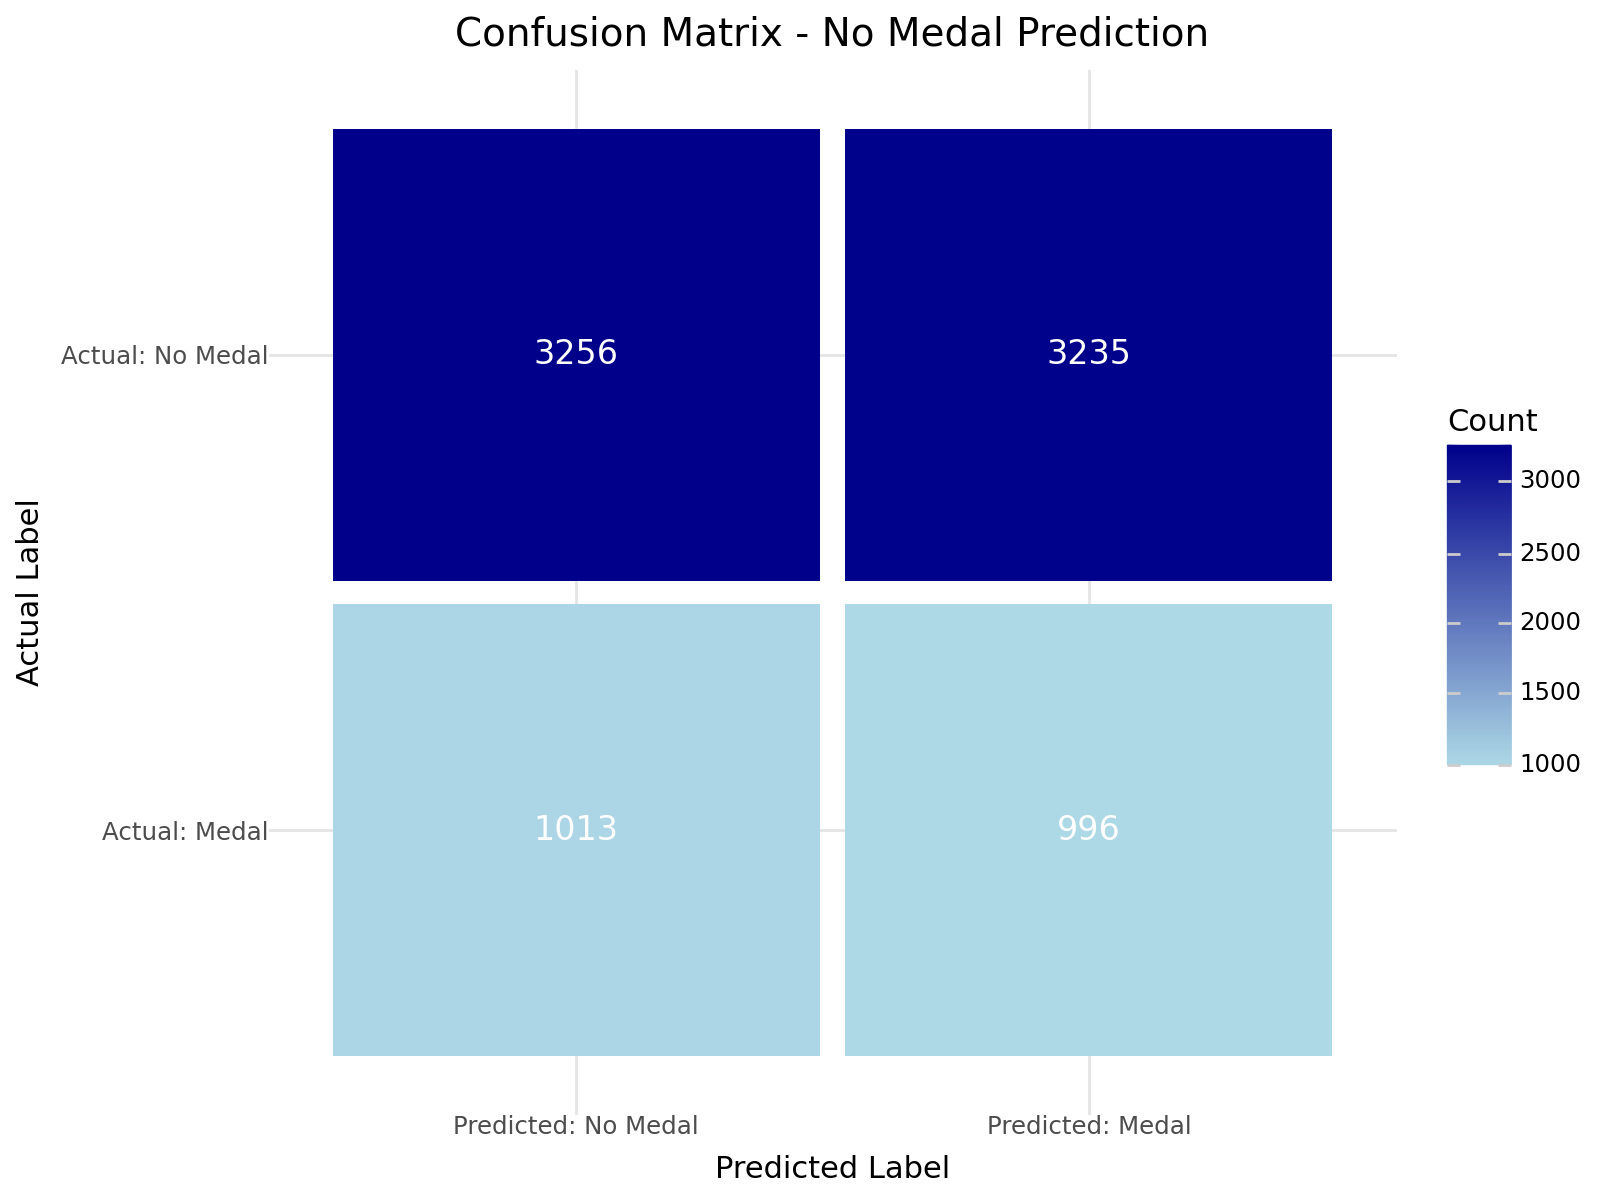

In [62]:
from sklearn.metrics import confusion_matrix
from plotnine import *
import pandas as pd

# Get predictions from best model
y_pred = grid_search.predict(X)

# Create confusion matrix
cm = confusion_matrix(y, y_pred)

# Flip both axes so TP is top-left and TN is bottom-right
cm = cm[::-1, ::-1]

# Convert to dataframe for ggplot
cm_df = pd.DataFrame(cm, 
    index=['Actual: No Medal', 'Actual: Medal'],
    columns=['Predicted: No Medal', 'Predicted: Medal']
).reset_index().rename(columns={'index': 'Actual'})

# Melt for ggplot
cm_melted = cm_df.melt(id_vars='Actual', 
                        var_name='Predicted', 
                        value_name='Count')

# Create ggplot confusion matrix for No Medal prediction
(ggplot(cm_melted, aes(x='Predicted', y='Actual', fill='Count')) +
 geom_tile(aes(width=0.95, height=0.95)) +
 geom_text(aes(label='Count'), size=12, color='white') +
 scale_fill_gradient(low='lightblue', high='darkblue') +
 scale_x_discrete(limits=['Predicted: No Medal', 'Predicted: Medal']) +
 labs(title='Confusion Matrix - No Medal Prediction',
      x='Predicted Label',
      y='Actual Label',
      fill='Count') +
 theme_minimal() +
 theme(figure_size=(8, 6),
       plot_title=element_text(size=14)))


In [40]:
# Investigate notes column for data leakage
print("Sample notes by medal outcome:")
print("\n--- Athletes WITH medals ---")
print(athletes_df[athletes_df['medal'] != 'No Medal']['notes'].value_counts().head(10))
print("\n--- Athletes WITHOUT medals ---")
print(athletes_df[athletes_df['medal'] == 'No Medal']['notes'].value_counts().head(10))

# Check for null/missing
print(f"\nMissing notes: {athletes_df['notes'].isna().sum()}")
print(f"Unique note values: {athletes_df['notes'].nunique()}")


Sample notes by medal outcome:

--- Athletes WITH medals ---
notes
-                             648
National Record               104
Equipment issue                97
Photo-finish silver            93
Personal Best                  92
Weather-affected               89
Disqualified (false start)     87
Olympic Debut                  86
Final Appearance               84
Withdrew - injury              84
Name: count, dtype: int64

--- Athletes WITHOUT medals ---
notes
-                             2151
Personal Best                  299
Olympic Debut                  291
Equipment issue                283
Comeback after injury          279
Disqualified (false start)     275
Record broken next day         275
National Record                272
Weather-affected               271
Oldest medalist                271
Name: count, dtype: int64

Missing notes: 0
Unique note values: 17


In [41]:
# Diagnose data leakage - check for perfect splits in categorical features
print("Checking for perfect leakage in categorical features:\n")

for col in ['gender', 'nationality', 'sport', 'event', 'team_or_individual']:
    print(f"\n=== {col} ===")
    ct = pd.crosstab(athletes_df[col], athletes_df['medal_binary'])
    # Check if any category has ONLY medals or NO medals
    leaky = ct[(ct[0] == 0) | (ct[1] == 0)]
    if len(leaky) > 0:
        print(f"🚨 LEAKAGE FOUND - These {col} values perfectly predict the target:")
        print(leaky)
    else:
        print(f"✓ Mixed medals in all {col} categories")

# Check for perfect numeric lean
print("\n\n=== Numeric features ===")
print(f"Height range: {athletes_df['height_cm'].min()} - {athletes_df['height_cm'].max()}")
print(f"Weight range: {athletes_df['weight_kg'].min()} - {athletes_df['weight_kg'].max()}")

print("\nRecord holder distribution:")
print(athletes_df.groupby('is_record_holder_bin')['medal_binary'].value_counts())


Checking for perfect leakage in categorical features:


=== gender ===
✓ Mixed medals in all gender categories

=== nationality ===
✓ Mixed medals in all nationality categories

=== sport ===
✓ Mixed medals in all sport categories

=== event ===
🚨 LEAKAGE FOUND - These event values perfectly predict the target:
medal_binary    0   1
event                
4x10km Relay M  0  15
61kg            0  14
Discus Throw    0   6
Madison         0  17
Moguls W        0  15
Pole Vault      0   9

=== team_or_individual ===
✓ Mixed medals in all team_or_individual categories


=== Numeric features ===
Height range: 145.0 - 215.0
Weight range: 40.1 - 149.7

Record holder distribution:
is_record_holder_bin  medal_binary
0                     1               6491
                      0               2009
Name: count, dtype: int64


In [43]:
# Check sport and team_or_individual for leakage
print("=== SPORT ===")
ct_sport = pd.crosstab(athletes_df['sport'], athletes_df['medal_binary'])
leaky_sport = ct_sport[(ct_sport[0] == 0) | (ct_sport[1] == 0)]
if len(leaky_sport) > 0:
    print(f"🚨 LEAKAGE FOUND in sport:")
    print(leaky_sport)
else:
    print("✓ Mixed medals in all sports")

print("\n=== TEAM_OR_INDIVIDUAL ===")
ct_team = pd.crosstab(athletes_df['team_or_individual'], athletes_df['medal_binary'])
print(ct_team)


=== SPORT ===
✓ Mixed medals in all sports

=== TEAM_OR_INDIVIDUAL ===
medal_binary           0     1
team_or_individual            
Individual          1341  4386
Team                 668  2105
